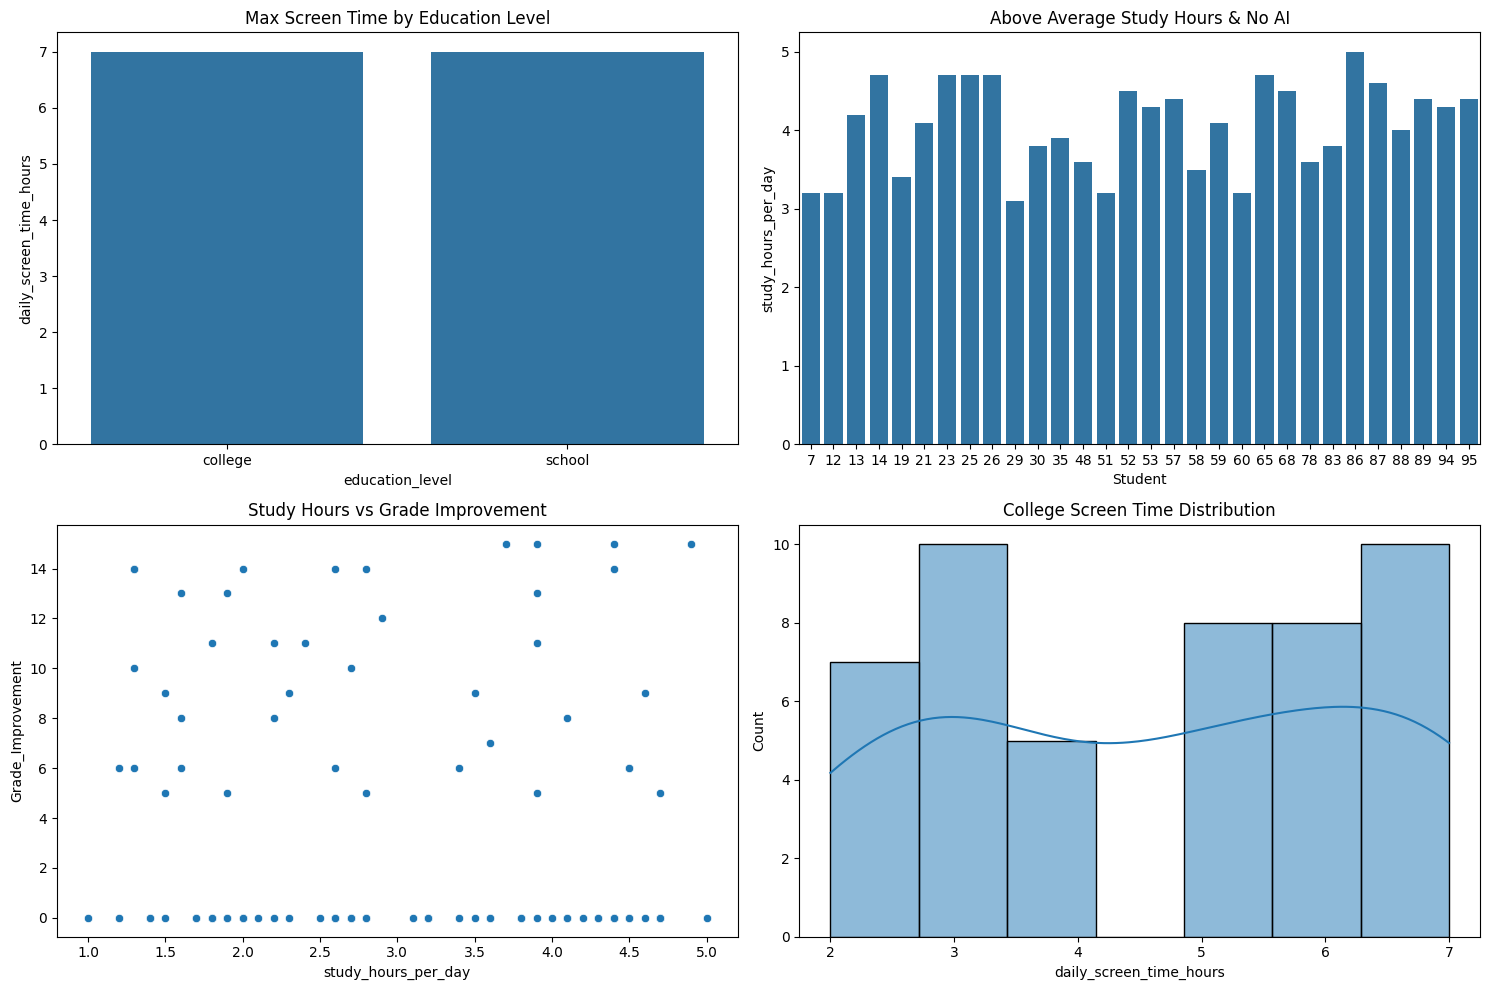

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Kelas F_Student AI Usage.csv")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# =========================
# Grafik 1
# =========================
max_screen = df.groupby("education_level")["daily_screen_time_hours"].max().reset_index()

sns.barplot(
    data=max_screen,
    x="education_level",
    y="daily_screen_time_hours",
    ax=axes[0,0]
)

axes[0,0].set_title("Max Screen Time by Education Level")

# =========================
# Grafik 2
# =========================
avg_study = df["study_hours_per_day"].mean()

filtered = df[
    (df["study_hours_per_day"] > avg_study) &
    (df["uses_ai"] == "No")
]

sns.barplot(
    data=filtered,
    x=filtered.index,
    y="study_hours_per_day",
    ax=axes[0,1]
)

axes[0,1].set_title("Above Average Study Hours & No AI")
axes[0,1].set_xlabel("Student")

# =========================
# Grafik 3
# =========================
df["Grade_Improvement"] = (
    df["grades_after_ai"] -
    df["grades_before_ai"]
)

sns.scatterplot(
    data=df,
    x="study_hours_per_day",
    y="Grade_Improvement",
    ax=axes[1,0]
)

axes[1,0].set_title("Study Hours vs Grade Improvement")

# =========================
# Grafik 4
# =========================
college = df[df["education_level"] == "college"]

sns.histplot(
    data=college,
    x="daily_screen_time_hours",
    kde=True,
    ax=axes[1,1]
)

axes[1,1].set_title("College Screen Time Distribution")

plt.tight_layout()
plt.show()